# Lab Assignment - 8

### CS22B1093 - Rohan G

------------------------

### RNN-Based Sentiment Analysis for Movie Reviews

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import time
import random

In [41]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package punkt to /home/rzeta/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/rzeta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rzeta/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [42]:
from nltk.tokenize import word_tokenize
nltk.data.path.append('/home/rzeta/nltk_data')


Training dataset shape: (67349, 3)
Validation dataset shape: (872, 3)

Sample of training data:
   idx                                           sentence  label
0    0       hide new secretions from the parental units       0
1    1               contains no wit , only labored gags       0
2    2  that loves its characters and communicates som...      1
3    3  remains utterly satisfied to remain the same t...      0
4    4  on the worst revenge-of-the-nerds clichés the ...      0

Missing values in training data:
idx         0
sentence    0
label       0
dtype: int64

Class distribution in training data:
label
1    37569
0    29780
Name: count, dtype: int64
label
1    55.8
0    44.2
Name: proportion, dtype: float64

Sentence length statistics:
count    67349.00000
mean        53.50559
std         43.40738
min          2.00000
25%         21.00000
50%         39.00000
75%         74.00000
max        268.00000
Name: sentence_length, dtype: float64

Word count statistics:
count    67349.

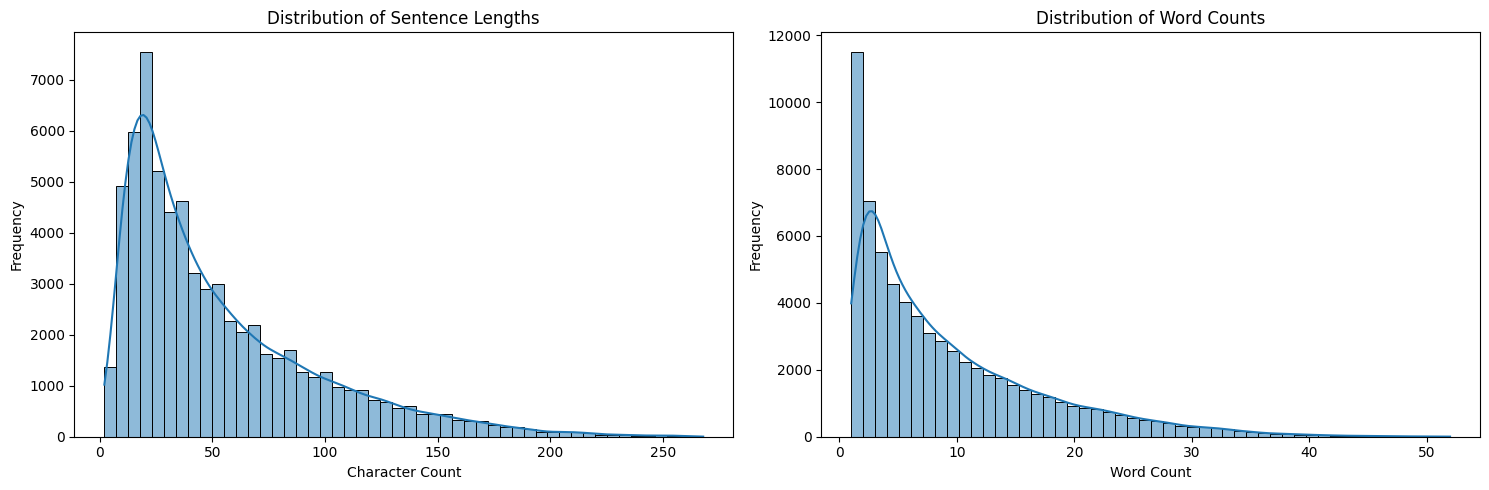

In [ ]:
%matplotlib inline

train_data = pd.read_parquet('sst2_sentiment_dataset/sst2_train.parquet')
val_data = pd.read_parquet('sst2_sentiment_dataset/sst2_valid.parquet')

# Display information about the datasets
print("Training dataset shape:", train_data.shape)
print("Validation dataset shape:", val_data.shape)

# Display the first few rows of the training dataset
print("\nSample of training data:")
print(train_data.head())

# Check for missing values
print("\nMissing values in training data:")
print(train_data.isnull().sum())

# Display class distribution in training data
print("\nClass distribution in training data:")
print(train_data['label'].value_counts())
print(train_data['label'].value_counts(normalize=True).round(3) * 100)

# Display basic statistics about sentence lengths
train_data['sentence_length'] = train_data['sentence'].apply(len)
train_data['word_count'] = train_data['sentence'].apply(lambda x: len(x.split()))

print("\nSentence length statistics:")
print(train_data['sentence_length'].describe())

print("\nWord count statistics:")
print(train_data['word_count'].describe())

# Visualize the distribution of sentence lengths and word counts
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_data['sentence_length'], bins=50, kde=True)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(train_data['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
plt.savefig('sentence_distributions.png')
plt.close()

In [44]:
import os
os.environ['NLTK_DATA'] = '/home/rzeta/nltk_data'

In [51]:
train_df, test_df = train_test_split(train_data, test_size=5000, random_state=42, stratify=train_data['label'])

print(f"After splitting: Training set size: {train_df.shape[0]}, Test set size: {test_df.shape[0]}")

# Function for text preprocessing
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # If no tokens remain, add a placeholder token
    if len(tokens) == 0:
        tokens = ["<unk>"]
    
    # Join tokens back into text
    processed_text = ' '.join(tokens)
    
    return processed_text

# Apply preprocessing to all datasets
train_df['processed_text'] = train_df['sentence'].apply(preprocess_text)
test_df['processed_text'] = test_df['sentence'].apply(preprocess_text)
val_data['processed_text'] = val_data['sentence'].apply(preprocess_text)

# Display a few examples of original vs processed text
comparison_df = pd.DataFrame({
    'Original': train_df['sentence'].head(3).values,
    'Processed': train_df['processed_text'].head(3).values
})
print("\nText preprocessing examples:")
print(comparison_df)

After splitting: Training set size: 62349, Test set size: 5000

Text preprocessing examples:
                                            Original  \
0       comes the first lousy guy ritchie imitation    
1  an underlying seriousness that sneaks up on th...   
2  deteriorates into a terribly obvious melodrama...   

                                           Processed  
0             come first lousy guy ritchie imitation  
1  underlying seriousness sneak viewer providing ...  
2  deteriorates terribly obvious melodrama roughh...  


In [52]:
def build_vocab(texts, max_vocab_size=10000):
    # Tokenize all texts
    all_words = []
    for text in texts:
        all_words.extend(text.split())
    
    # Count word frequencies
    word_counts = Counter(all_words)
    
    # Sort by frequency and select top words
    vocab = ["<PAD>", "<UNK>"]  # Special tokens
    vocab.extend([word for word, _ in word_counts.most_common(max_vocab_size - len(vocab))])
    
    # Create word-to-index and index-to-word mappings
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for idx, word in enumerate(vocab)}
    
    return vocab, word2idx, idx2word

# Configure vocabulary
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100

# Build vocabulary
vocab, word2idx, idx2word = build_vocab(train_df['processed_text'], MAX_VOCAB_SIZE)
vocab_size = len(vocab)
print(f"\nVocabulary size: {vocab_size}")

# Convert text to sequences of indices
def text_to_sequence(text, word2idx, max_length=MAX_SEQUENCE_LENGTH):
    words = text.split()
    sequence = [word2idx.get(word, word2idx["<UNK>"]) for word in words]
    
    # Truncate or pad to max_length
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    
    return sequence

# Create sequences for all datasets
train_sequences = [text_to_sequence(text, word2idx) for text in train_df['processed_text']]
test_sequences = [text_to_sequence(text, word2idx) for text in test_df['processed_text']]
val_sequences = [text_to_sequence(text, word2idx) for text in val_data['processed_text']]


Vocabulary size: 10000


In [53]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        length = torch.tensor(len(self.sequences[idx]), dtype=torch.long)
        return sequence, label, length

# Custom collate function for padding sequences in batches
def collate_fn(batch):
    sequences, labels, lengths = zip(*batch)
    
    # Pad sequences
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=word2idx["<PAD>"])
    
    # Convert to tensors
    labels = torch.tensor(labels, dtype=torch.float)
    lengths = torch.tensor(lengths, dtype=torch.long)
    
    return padded_sequences, labels, lengths

# Create datasets
train_dataset = SentimentDataset(train_sequences, train_df['label'].values)
test_dataset = SentimentDataset(test_sequences, test_df['label'].values)
val_dataset = SentimentDataset(val_sequences, val_data['label'].values)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

In [54]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx):
        super().__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        # RNN layer (LSTM)
        self.rnn = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers, 
            bidirectional=bidirectional, 
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text, text_lengths):
        # text shape: [batch size, sequence length]
        
        # Get embeddings
        embedded = self.embedding(text)
        # embedded shape: [batch size, sequence length, embedding dim]
        
        # Pack padded sequences
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # Pass through RNN
        packed_output, (hidden, cell) = self.rnn(packed_embedded)
        
        # Unpack sequences
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # If bidirectional, concatenate the final forward and backward hidden states
        if self.rnn.bidirectional:
            hidden = self.dropout(torch.cat([hidden[-2], hidden[-1]], dim=1))
        else:
            hidden = self.dropout(hidden[-1])
        
        # Apply fully connected layer
        return self.fc(hidden).squeeze(1)

In [55]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
N_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT = 0.5
LEARNING_RATE = 0.001
N_EPOCHS = 10

# Initialize the model
model = SentimentRNN(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=1,  # Binary classification
    n_layers=N_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout=DROPOUT,
    pad_idx=word2idx["<PAD>"]
)

# Move model to device
model = model.to(device)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training function
def train_model(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    
    model.train()
    
    for batch in iterator:
        # Get batch data
        text, labels, text_lengths = batch
        
        # Move to device
        text = text.to(device)
        labels = labels.to(device)
        text_lengths = text_lengths.to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(text, text_lengths)
        
        # Calculate loss
        loss = criterion(predictions, labels)
        
        # Calculate accuracy
        predicted_labels = torch.round(torch.sigmoid(predictions))
        correct = (predicted_labels == labels).float()
        accuracy = correct.sum() / len(correct)
        
        # Backward pass
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += accuracy.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# Evaluation function
def evaluate_model(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0
    
    model.eval()
    
    with torch.no_grad():
        for batch in iterator:
            # Get batch data
            text, labels, text_lengths = batch
            
            # Move to device
            text = text.to(device)
            labels = labels.to(device)
            text_lengths = text_lengths.to(device)
            
            # Forward pass
            predictions = model(text, text_lengths)
            
            # Calculate loss
            loss = criterion(predictions, labels)
            
            # Calculate accuracy
            predicted_labels = torch.round(torch.sigmoid(predictions))
            correct = (predicted_labels == labels).float()
            accuracy = correct.sum() / len(correct)
            
            epoch_loss += loss.item()
            epoch_acc += accuracy.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# Function to compute training time
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [56]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0

# Training loop
for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Train
    train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
    
    # Validate
    val_loss, val_acc = evaluate_model(model, val_loader, criterion)
    
    # Track metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best-rnn-model.pt')
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

Epoch: 01 | Time: 0m 8s
	Train Loss: 0.455 | Train Acc: 77.51%
	 Val. Loss: 0.543 |  Val. Acc: 76.87%
Epoch: 02 | Time: 0m 8s
	Train Loss: 0.246 | Train Acc: 89.85%
	 Val. Loss: 0.546 |  Val. Acc: 78.08%
Epoch: 03 | Time: 0m 7s
	Train Loss: 0.173 | Train Acc: 93.08%
	 Val. Loss: 0.608 |  Val. Acc: 78.37%
Early stopping at epoch 4


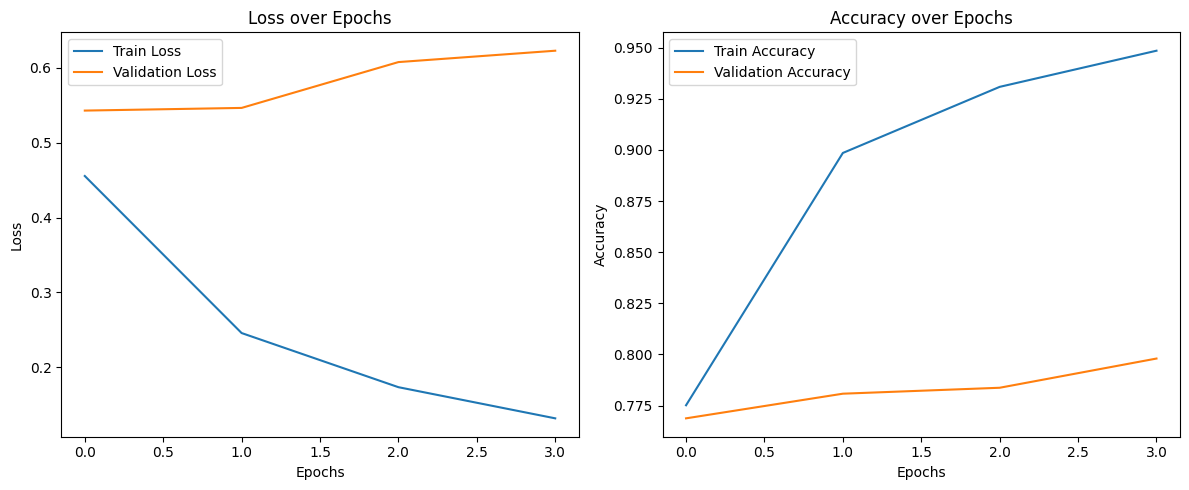

In [57]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.tight_layout()
plt.show()
plt.savefig('training_metrics.png')
plt.close()

In [58]:
model.load_state_dict(torch.load('best-rnn-model.pt'))

# Evaluate on test set
test_loss, test_acc = evaluate_model(model, test_loader, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

# Generate predictions for detailed metrics
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        text, labels, text_lengths = batch
        
        # Move to device
        text = text.to(device)
        text_lengths = text_lengths.to(device)
        
        # Forward pass
        predictions = model(text, text_lengths)
        
        # Convert predictions to binary (0 or 1)
        predicted_labels = torch.round(torch.sigmoid(predictions))
        
        # Append to lists
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted_labels.cpu().numpy())

Test Loss: 0.335 | Test Acc: 85.54%


In [59]:
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.close()

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# Calculate additional metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
accuracy = accuracy_score(y_true, y_pred)

print("\nSummary Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.82      0.83      2211
    Positive       0.86      0.89      0.87      2789

    accuracy                           0.86      5000
   macro avg       0.86      0.85      0.85      5000
weighted avg       0.86      0.86      0.86      5000


Summary Metrics:
Accuracy: 0.8566
Precision: 0.8602
Recall: 0.8871
F1 Score: 0.8734


In [60]:
def predict_sentiment(model, text, word2idx, device):
    # Preprocess the text
    processed_text = preprocess_text(text)
    
    # Convert to sequence
    sequence = text_to_sequence(processed_text, word2idx)
    
    # Convert to tensor
    sequence_tensor = torch.tensor([sequence], dtype=torch.long).to(device)
    sequence_length = torch.tensor([len(sequence)], dtype=torch.long).to(device)
    
    # Set model to evaluation mode
    model.eval()
    
    # Get prediction
    with torch.no_grad():
        prediction = torch.sigmoid(model(sequence_tensor, sequence_length))
    
    # Convert to sentiment and probability
    sentiment = "Positive" if prediction.item() > 0.5 else "Negative"
    probability = prediction.item() if sentiment == "Positive" else 1 - prediction.item()
    
    return sentiment, probability

# Example predictions
example_reviews = [
    "This movie was amazing and I loved every minute of it!",
    "The film was boring and the acting was terrible.",
    "It was neither great nor terrible, just an average film."
]

print("\nExample Predictions:")
for review in example_reviews:
    sentiment, probability = predict_sentiment(model, review, word2idx, device)
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment} (confidence: {probability:.4f})\n")


Example Predictions:
Review: This movie was amazing and I loved every minute of it!
Sentiment: Negative (confidence: 0.7128)

Review: The film was boring and the acting was terrible.
Sentiment: Negative (confidence: 0.9931)

Review: It was neither great nor terrible, just an average film.
Sentiment: Negative (confidence: 0.9782)



---------------

### LSTM based model for sentiment analysis

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import time
import random

In [62]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package punkt to /home/rzeta/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/rzeta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rzeta/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
train_data = pd.read_parquet('sst2_sentiment_dataset/sst2_train.parquet')
val_data = pd.read_parquet('sst2_sentiment_dataset/sst2_valid.parquet')

# Split the provided train dataset into training and testing sets
train_df, test_df = train_test_split(train_data, test_size=5000, random_state=42, stratify=train_data['label'])

print(f"Training set size: {train_df.shape[0]}, Test set size: {test_df.shape[0]}, Validation set size: {val_data.shape[0]}")

# Function for text preprocessing
def preprocess_text(text):
    """
    Apply multiple preprocessing steps to clean text data:
    1. Lowercasing
    2. Removing HTML tags
    3. Removing URLs
    4. Removing special characters and numbers
    5. Tokenizing
    6. Removing stopwords
    7. Lemmatizing
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Join tokens back into text
    processed_text = ' '.join(tokens)
    
    return processed_text

# Apply preprocessing to all datasets
train_df['processed_text'] = train_df['sentence'].apply(preprocess_text)
test_df['processed_text'] = test_df['sentence'].apply(preprocess_text)
val_data['processed_text'] = val_data['sentence'].apply(preprocess_text)

FileNotFoundError: [Errno 2] No such file or directory: 'sst2_train.parquet'

In [64]:
def build_vocab(texts, max_vocab_size=10000):
    """
    Build vocabulary from the training data:
    1. Tokenize all texts
    2. Count word frequencies
    3. Select top words based on frequency
    4. Create word-to-index and index-to-word mappings
    """
    # Tokenize all texts
    all_words = []
    for text in texts:
        all_words.extend(text.split())
    
    # Count word frequencies
    word_counts = Counter(all_words)
    
    # Sort by frequency and select top words
    vocab = ["<PAD>", "<UNK>"]  # Special tokens
    vocab.extend([word for word, _ in word_counts.most_common(max_vocab_size - len(vocab))])
    
    # Create word-to-index and index-to-word mappings
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for idx, word in enumerate(vocab)}
    
    return vocab, word2idx, idx2word

# Configure vocabulary
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100

# Build vocabulary
vocab, word2idx, idx2word = build_vocab(train_df['processed_text'], MAX_VOCAB_SIZE)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Convert text to sequences of indices
def text_to_sequence(text, word2idx, max_length=MAX_SEQUENCE_LENGTH):
    """
    Convert text to a sequence of word indices using the vocabulary
    """
    words = text.split()
    sequence = [word2idx.get(word, word2idx["<UNK>"]) for word in words]
    
    # Truncate if needed (we'll handle padding in the DataLoader)
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    
    return sequence

# Create sequences for all datasets
train_sequences = [text_to_sequence(text, word2idx) for text in train_df['processed_text']]
test_sequences = [text_to_sequence(text, word2idx) for text in test_df['processed_text']]
val_sequences = [text_to_sequence(text, word2idx) for text in val_data['processed_text']]


Vocabulary size: 10000


In [65]:
class SentimentDataset(Dataset):
    """
    Custom PyTorch Dataset for sentiment analysis
    """
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        length = torch.tensor(len(self.sequences[idx]), dtype=torch.long)
        return sequence, label, length

# Custom collate function for padding sequences in batches
def collate_fn(batch):
    """
    Custom collate function for padding sequences in a batch
    """
    sequences, labels, lengths = zip(*batch)
    
    # Pad sequences
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=word2idx["<PAD>"])
    
    # Convert to tensors
    labels = torch.tensor(labels, dtype=torch.float)
    lengths = torch.tensor(lengths, dtype=torch.long)
    
    return padded_sequences, labels, lengths

# Create datasets
train_dataset = SentimentDataset(train_sequences, train_df['label'].values)
test_dataset = SentimentDataset(test_sequences, test_df['label'].values)
val_dataset = SentimentDataset(val_sequences, val_data['label'].values)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

In [66]:
class LSTMModel(nn.Module):
    """
    LSTM model for sentiment analysis
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx):
        super().__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        # LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers, 
            bidirectional=bidirectional, 
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text, text_lengths):
        # text shape: [batch size, sequence length]
        
        # Get embeddings
        embedded = self.embedding(text)
        # embedded shape: [batch size, sequence length, embedding dim]
        
        # Pack padded sequences
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # Pass through LSTM
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        # If bidirectional, concatenate the final forward and backward hidden states
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat([hidden[-2], hidden[-1]], dim=1))
        else:
            hidden = self.dropout(hidden[-1])
        
        # Apply fully connected layer
        return self.fc(hidden).squeeze(1)

In [67]:
def train_model(model, iterator, optimizer, criterion):
    """
    Train the model for one epoch
    """
    epoch_loss = 0
    epoch_acc = 0
    
    model.train()
    
    for batch in iterator:
        # Get batch data
        text, labels, text_lengths = batch
        
        # Move to device
        text = text.to(device)
        labels = labels.to(device)
        text_lengths = text_lengths.to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(text, text_lengths)
        
        # Calculate loss
        loss = criterion(predictions, labels)
        
        # Calculate accuracy
        predicted_labels = torch.round(torch.sigmoid(predictions))
        correct = (predicted_labels == labels).float()
        accuracy = correct.sum() / len(correct)
        
        # Backward pass
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += accuracy.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# Evaluation function
def evaluate_model(model, iterator, criterion):
    """
    Evaluate the model on validation or test data
    """
    epoch_loss = 0
    epoch_acc = 0
    
    model.eval()
    
    with torch.no_grad():
        for batch in iterator:
            # Get batch data
            text, labels, text_lengths = batch
            
            # Move to device
            text = text.to(device)
            labels = labels.to(device)
            text_lengths = text_lengths.to(device)
            
            # Forward pass
            predictions = model(text, text_lengths)
            
            # Calculate loss
            loss = criterion(predictions, labels)
            
            # Calculate accuracy
            predicted_labels = torch.round(torch.sigmoid(predictions))
            correct = (predicted_labels == labels).float()
            accuracy = correct.sum() / len(correct)
            
            epoch_loss += loss.item()
            epoch_acc += accuracy.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# Function to compute training time
def epoch_time(start_time, end_time):
    """
    Calculate time taken for an epoch
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

# Generate predictions for detailed evaluation
def get_predictions(model, iterator):
    """
    Generate predictions for the entire dataset
    """
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for batch in iterator:
            text, labels, text_lengths = batch
            
            # Move to device
            text = text.to(device)
            text_lengths = text_lengths.to(device)
            
            # Forward pass
            predictions = model(text, text_lengths)
            
            # Convert predictions to binary (0 or 1)
            predicted_labels = torch.round(torch.sigmoid(predictions))
            
            # Append to lists
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted_labels.cpu().numpy())
    
    return y_true, y_pred

LSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
The LSTM model has 3,648,001 trainable parameters
Epoch: 01 | Time: 0m 9s
	Train Loss: 0.447 | Train Acc: 78.00%
	 Val. Loss: 0.521 |  Val. Acc: 77.12%
Epoch: 02 | Time: 0m 9s
	Train Loss: 0.244 | Train Acc: 89.91%
	 Val. Loss: 0.574 |  Val. Acc: 77.10%
Epoch: 03 | Time: 0m 8s
	Train Loss: 0.172 | Train Acc: 93.01%
	 Val. Loss: 0.599 |  Val. Acc: 79.20%
Early stopping at epoch 4


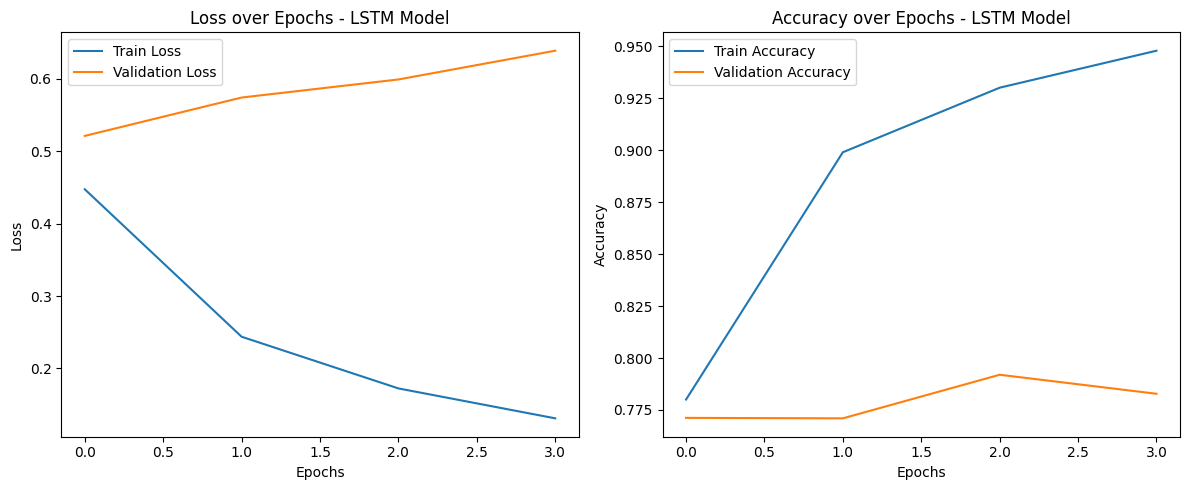

In [68]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
N_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT = 0.5
LEARNING_RATE = 0.001
N_EPOCHS = 10

# Initialize LSTM model
lstm_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=1,  # Binary classification
    n_layers=N_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout=DROPOUT,
    pad_idx=word2idx["<PAD>"]
)

# Move model to device
lstm_model = lstm_model.to(device)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# Print model architecture and parameter count
print(lstm_model)
print(f'The LSTM model has {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,} trainable parameters')

# Track metrics
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 3
trigger_times = 0

# Training loop
for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Train
    train_loss, train_acc = train_model(lstm_model, train_loader, optimizer, criterion)
    
    # Validate
    val_loss, val_acc = evaluate_model(lstm_model, val_loader, criterion)
    
    # Track metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(lstm_model.state_dict(), 'best-lstm-model.pt')
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

# Plot training metrics
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs - LSTM Model')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs - LSTM Model')

plt.tight_layout()
plt.show()
plt.savefig('lstm_training_metrics.png')
plt.close()

In [69]:
lstm_model.load_state_dict(torch.load('best-lstm-model.pt'))

# Evaluate on test set
test_loss, test_acc = evaluate_model(lstm_model, test_loader, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

# Get predictions for detailed metrics
y_true, y_pred = get_predictions(lstm_model, test_loader)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LSTM Model')
plt.savefig('lstm_confusion_matrix.png')
plt.close()

# Generate classification report
print("\nClassification Report for LSTM Model:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"LSTM Model Accuracy: {accuracy:.4f}")

Test Loss: 0.324 | Test Acc: 86.41%

Classification Report for LSTM Model:
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      2211
    Positive       0.88      0.87      0.88      2789

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000

LSTM Model Accuracy: 0.8640


In [70]:
def predict_sentiment(model, text, word2idx, device):
    """
    Predict sentiment for a new review
    """
    # Preprocess the text
    processed_text = preprocess_text(text)
    
    # Convert to sequence
    sequence = text_to_sequence(processed_text, word2idx)
    
    # Convert to tensor
    sequence_tensor = torch.tensor([sequence], dtype=torch.long).to(device)
    sequence_length = torch.tensor([len(sequence)], dtype=torch.long).to(device)
    
    # Set model to evaluation mode
    model.eval()
    
    # Get prediction
    with torch.no_grad():
        prediction = torch.sigmoid(model(sequence_tensor, sequence_length))
    
    # Convert to sentiment and probability
    sentiment = "Positive" if prediction.item() > 0.5 else "Negative"
    probability = prediction.item() if sentiment == "Positive" else 1 - prediction.item()
    
    return sentiment, probability

# Example predictions
example_reviews = [
    "This movie was amazing and I loved every minute of it!",
    "The film was boring and the acting was terrible.",
    "It was neither great nor terrible, just an average film."
]

print("\nExample LSTM Predictions:")
for review in example_reviews:
    sentiment, probability = predict_sentiment(lstm_model, review, word2idx, device)
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment} (confidence: {probability:.4f})\n")


Example LSTM Predictions:
Review: This movie was amazing and I loved every minute of it!
Sentiment: Positive (confidence: 0.6904)

Review: The film was boring and the acting was terrible.
Sentiment: Negative (confidence: 0.9823)

Review: It was neither great nor terrible, just an average film.
Sentiment: Negative (confidence: 0.9601)



---------------

### Comparison between RNN and LSTM Models

Generating predictions for RNN model...
Generating predictions for LSTM model...

Model Comparison:
      Metric       RNN      LSTM Improvement (%) Absolute Improvement
0   Accuracy  0.856600  0.864000           0.86%               0.0074
1  Precision  0.860223  0.882204           2.56%               0.0220
2     Recall  0.887056  0.872714          -1.62%              -0.0143
3   F1 Score  0.873433  0.877433           0.46%               0.0040


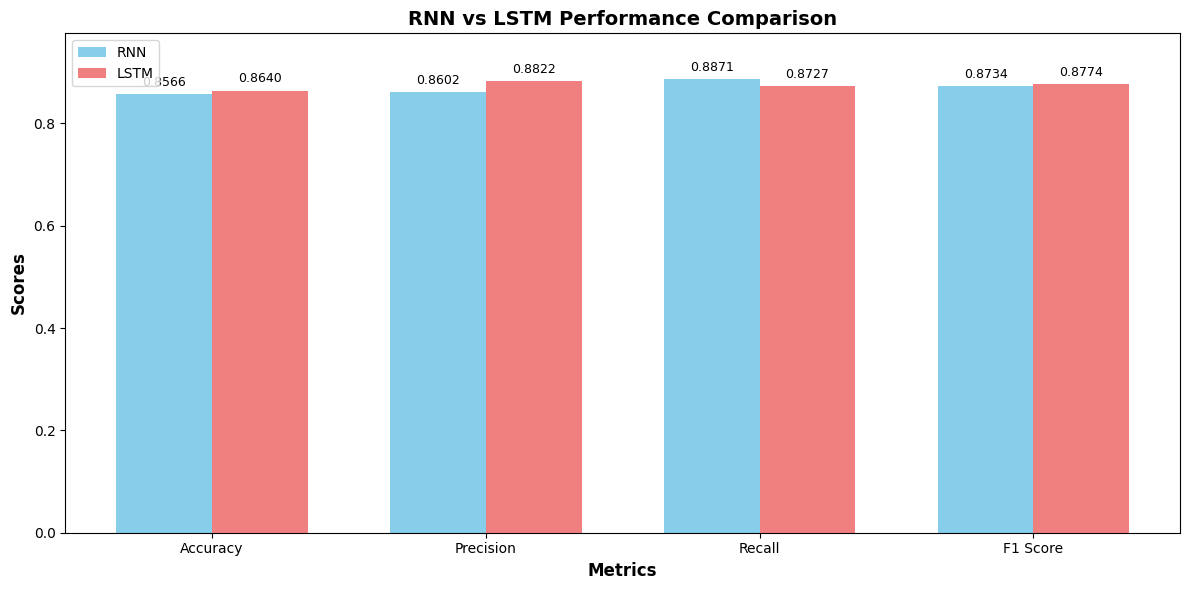


Error Analysis:
The models disagree on 607 samples (12.14% of test data)
In disagreements, RNN is correct: 285 times (46.95%)
In disagreements, LSTM is correct: 322 times (53.05%)


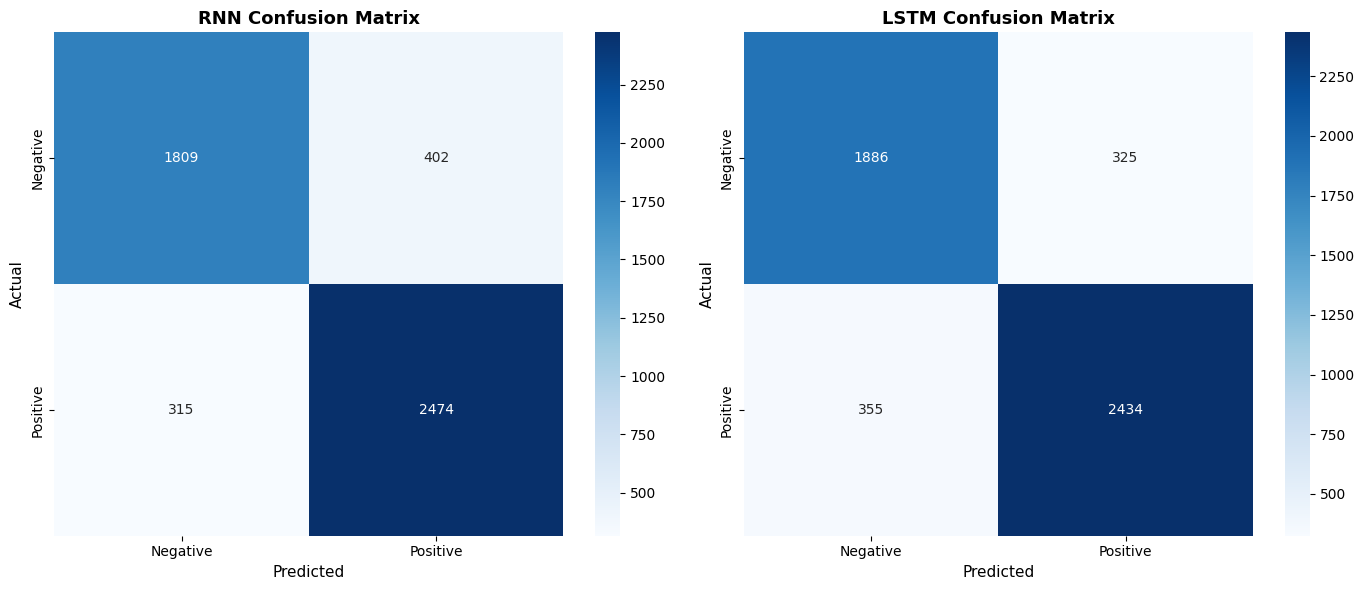


Performance by Sentence Length:
  Length Range  Count  RNN Accuracy  LSTM Accuracy  Improvement  \
0         0-10   4468      0.849373       0.858326     0.008953   
1        11-20    518      0.918919       0.913127    -0.005792   
2        21-30     14      0.857143       0.857143     0.000000   

   Improvement (%)  
0         1.054018  
1        -0.630252  
2         0.000000  


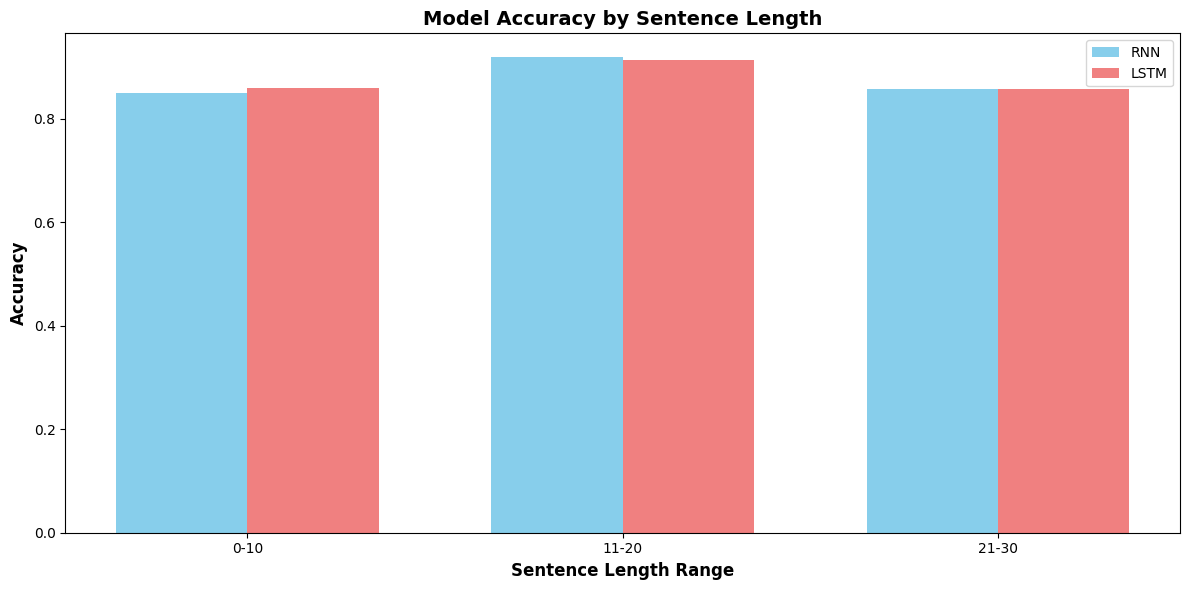


===== Comprehensive Comparison Summary =====
Total test samples: 5000
RNN overall accuracy: 0.8566
LSTM overall accuracy: 0.8640
Absolute improvement: 0.0074
Relative improvement: 0.86%

Key Findings:
1. LSTM outperforms RNN in overall accuracy
2. LSTM is correct 322 out of 607 times when models disagree
3. LSTM performs worse on longer sentences
4. The models disagree on 12.14% of the test samples


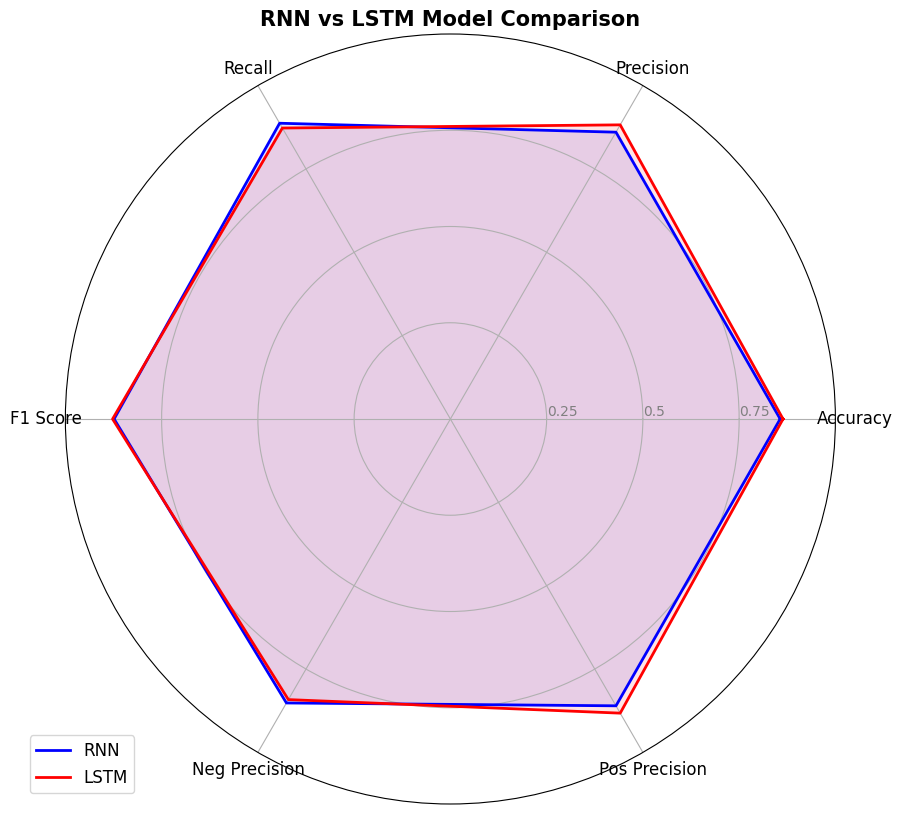

In [73]:
# Comparison of RNN vs LSTM Models for Sentiment Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import torch

# Load the pre-trained models (assuming they're already defined and trained)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load('best-rnn-model.pt'))  # Load RNN model
lstm_model.load_state_dict(torch.load('best-lstm-model.pt'))  # Load LSTM model

# Function to generate predictions
def get_predictions(model, data_loader, device):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for batch in data_loader:
            text, labels, text_lengths = batch
            
            # Move to device
            text = text.to(device)
            text_lengths = text_lengths.to(device)
            
            # Forward pass
            predictions = model(text, text_lengths)
            
            # Convert predictions to binary (0 or 1)
            predicted_labels = torch.round(torch.sigmoid(predictions))
            
            # Append to lists
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted_labels.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred)

# Get predictions for both models
print("Generating predictions for RNN model...")
rnn_true, rnn_pred = get_predictions(model, test_loader, device)

print("Generating predictions for LSTM model...")
lstm_true, lstm_pred = get_predictions(lstm_model, test_loader, device)

# Verify that the ground truth is the same for both models
assert np.array_equal(rnn_true, lstm_true), "Ground truth arrays should be identical"

# Calculate metrics for RNN model
rnn_accuracy = accuracy_score(rnn_true, rnn_pred)
rnn_precision, rnn_recall, rnn_f1, _ = precision_recall_fscore_support(rnn_true, rnn_pred, average='binary')

# Calculate metrics for LSTM model
lstm_accuracy = accuracy_score(lstm_true, lstm_pred)
lstm_precision, lstm_recall, lstm_f1, _ = precision_recall_fscore_support(lstm_true, lstm_pred, average='binary')

# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'RNN': [rnn_accuracy, rnn_precision, rnn_recall, rnn_f1],
    'LSTM': [lstm_accuracy, lstm_precision, lstm_recall, lstm_f1],
    'Improvement (%)': [
        f"{((lstm_accuracy - rnn_accuracy) / rnn_accuracy * 100):.2f}%",
        f"{((lstm_precision - rnn_precision) / rnn_precision * 100):.2f}%",
        f"{((lstm_recall - rnn_recall) / rnn_recall * 100):.2f}%",
        f"{((lstm_f1 - rnn_f1) / rnn_f1 * 100):.2f}%"
    ],
    'Absolute Improvement': [
        f"{(lstm_accuracy - rnn_accuracy):.4f}",
        f"{(lstm_precision - rnn_precision):.4f}",
        f"{(lstm_recall - rnn_recall):.4f}",
        f"{(lstm_f1 - rnn_f1):.4f}"
    ]
}

# Create DataFrame and save to CSV
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nModel Comparison:")
print(comparison_df)

# Visualize comparison with a bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rnn_values = [rnn_accuracy, rnn_precision, rnn_recall, rnn_f1]
lstm_values = [lstm_accuracy, lstm_precision, lstm_recall, lstm_f1]

plt.figure(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.35

rnn_bars = plt.bar(x - width/2, rnn_values, width, label='RNN', color='skyblue')
lstm_bars = plt.bar(x + width/2, lstm_values, width, label='LSTM', color='lightcoral')

plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Scores', fontsize=12, fontweight='bold')
plt.title('RNN vs LSTM Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, metrics, fontsize=10)
plt.ylim(0, max(max(rnn_values), max(lstm_values)) * 1.1)  # Adjust y-axis limit
plt.legend(fontsize=10)

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

add_labels(rnn_bars)
add_labels(lstm_bars)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=300)
plt.show()

# Error Analysis Section
# Find where models disagree
disagreement_mask = rnn_pred != lstm_pred
disagreement_count = np.sum(disagreement_mask)

print(f"\nError Analysis:")
print(f"The models disagree on {disagreement_count} samples ({disagreement_count/len(rnn_pred)*100:.2f}% of test data)")

# Check which model is correct in disagreements
rnn_correct_in_disagreements = np.sum((rnn_pred == rnn_true) & disagreement_mask)
lstm_correct_in_disagreements = np.sum((lstm_pred == lstm_true) & disagreement_mask)

print(f"In disagreements, RNN is correct: {rnn_correct_in_disagreements} times ({rnn_correct_in_disagreements/disagreement_count*100:.2f}%)")
print(f"In disagreements, LSTM is correct: {lstm_correct_in_disagreements} times ({lstm_correct_in_disagreements/disagreement_count*100:.2f}%)")

# Confusion matrices for both models
rnn_cm = confusion_matrix(rnn_true, rnn_pred)
lstm_cm = confusion_matrix(lstm_true, lstm_pred)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title('RNN Confusion Matrix', fontsize=13, fontweight='bold')

sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'], ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title('LSTM Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300)
plt.show()

# Advanced Analysis: Calculate performance difference by sentence length
def analyze_by_sentence_length(true_labels, rnn_preds, lstm_preds, texts, word2idx):
    lengths = [len(text_to_sequence(text, word2idx)) for text in texts]
    length_ranges = [(0, 10), (11, 20), (21, 30), (31, 40), (41, 50), (51, float('inf'))]
    
    results = []
    
    for min_len, max_len in length_ranges:
        # Find indices where sentence length is in the current range
        indices = [i for i, length in enumerate(lengths) if min_len <= length <= max_len]
        
        if not indices:  # Skip if no sentences in this range
            continue
        
        # Get subset of predictions and true labels for this length range
        range_true = true_labels[indices]
        range_rnn_preds = rnn_preds[indices]
        range_lstm_preds = lstm_preds[indices]
        
        # Calculate metrics
        rnn_acc = accuracy_score(range_true, range_rnn_preds)
        lstm_acc = accuracy_score(range_true, range_lstm_preds)
        
        results.append({
            'Length Range': f"{min_len}-{max_len if max_len != float('inf') else '∞'}",
            'Count': len(indices),
            'RNN Accuracy': rnn_acc,
            'LSTM Accuracy': lstm_acc,
            'Improvement': lstm_acc - rnn_acc,
            'Improvement (%)': (lstm_acc - rnn_acc) / rnn_acc * 100 if rnn_acc > 0 else float('inf')
        })
    
    return pd.DataFrame(results)

# Get text data from the test dataset
test_texts = test_df['processed_text'].values

# Analyze performance by sentence length
length_analysis = analyze_by_sentence_length(rnn_true, rnn_pred, lstm_pred, test_texts, word2idx)
print("\nPerformance by Sentence Length:")
print(length_analysis)

# Plot the results
plt.figure(figsize=(12, 6))
x = np.arange(len(length_analysis))
width = 0.35

rnn_acc_by_length = length_analysis['RNN Accuracy'].values
lstm_acc_by_length = length_analysis['LSTM Accuracy'].values

plt.bar(x - width/2, rnn_acc_by_length, width, label='RNN', color='skyblue')
plt.bar(x + width/2, lstm_acc_by_length, width, label='LSTM', color='lightcoral')

plt.xlabel('Sentence Length Range', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Accuracy by Sentence Length', fontsize=14, fontweight='bold')
plt.xticks(x, length_analysis['Length Range'])
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_by_length.png', dpi=300)
plt.show()

# Create a comprehensive summary of the comparison
print("\n===== Comprehensive Comparison Summary =====")
print(f"Total test samples: {len(rnn_true)}")
print(f"RNN overall accuracy: {rnn_accuracy:.4f}")
print(f"LSTM overall accuracy: {lstm_accuracy:.4f}")
print(f"Absolute improvement: {lstm_accuracy - rnn_accuracy:.4f}")
print(f"Relative improvement: {((lstm_accuracy - rnn_accuracy) / rnn_accuracy * 100):.2f}%")
print(f"\nKey Findings:")
print(f"1. LSTM {('outperforms' if lstm_accuracy > rnn_accuracy else 'underperforms')} RNN in overall accuracy")
print(f"2. LSTM is correct {lstm_correct_in_disagreements} out of {disagreement_count} times when models disagree")
print(f"3. LSTM performs {'better' if lstm_acc_by_length[-1] > rnn_acc_by_length[-1] else 'worse'} on longer sentences")
print(f"4. The models disagree on {disagreement_count/len(rnn_pred)*100:.2f}% of the test samples")

# For a more illustrative visualization, create a radar chart
def create_radar_chart(categories, values1, values2, title, model1_name='RNN', model2_name='LSTM'):
    # Number of variables
    N = len(categories)
    
    # We are going to plot the first line of the data frame.
    # But we need to repeat the first value to close the circular graph
    values1 = np.append(values1, values1[0])
    values2 = np.append(values2, values2[0])
    categories = np.append(categories, categories[0])
    
    # What will be the angle of each axis in the plot
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Initialise the plot
    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories[:-1], size=12)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.5", "0.75"], color="grey", size=10)
    plt.ylim(0, 1)
    
    # Plot data
    ax.plot(angles, values1, 'b-', linewidth=2, label=model1_name)
    ax.fill(angles, values1, 'b', alpha=0.1)
    ax.plot(angles, values2, 'r-', linewidth=2, label=model2_name)
    ax.fill(angles, values2, 'r', alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=12)
    plt.title(title, size=15, fontweight='bold')
    
    return fig

# Add some additional metrics for the radar chart
rnn_report = classification_report(rnn_true, rnn_pred, target_names=['Negative', 'Positive'], output_dict=True)
lstm_report = classification_report(lstm_true, lstm_pred, target_names=['Negative', 'Positive'], output_dict=True)

radar_metrics = [
    'Accuracy', 
    'Precision', 
    'Recall', 
    'F1 Score',
    'Neg Precision', 
    'Pos Precision'
]

radar_rnn_values = [
    rnn_accuracy,
    rnn_precision,
    rnn_recall,
    rnn_f1,
    rnn_report['Negative']['precision'],
    rnn_report['Positive']['precision']
]

radar_lstm_values = [
    lstm_accuracy,
    lstm_precision,
    lstm_recall,
    lstm_f1,
    lstm_report['Negative']['precision'],
    lstm_report['Positive']['precision']
]

radar_fig = create_radar_chart(
    categories=radar_metrics,
    values1=radar_rnn_values,
    values2=radar_lstm_values,
    title='RNN vs LSTM Model Comparison'
)

radar_fig.savefig('model_comparison_radar.png', dpi=300)
plt.show()

----------

---------